In [30]:
import os
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter, find_peaks
from scipy.stats import linregress
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
import random
import warnings
warnings.filterwarnings('ignore')

data_dir = "./dataset/NA-ion"
all_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.pkl')])
print(f"Total batteries: {len(all_files)}")

Total batteries: 64


In [31]:
#Single battery inspection
sample = pd.read_pickle(os.path.join(data_dir, all_files[0]))
print("Keys:", list(sample.keys()))
print("Nominal capacity:", sample['nominal_capacity_in_Ah'], "Ah")
print("Total cycles:", len(sample['cycle_data']))

# first cycle columns
cycle_df = pd.DataFrame(sample['cycle_data'][0])
print("\nColumns:", list(cycle_df.columns))
print(cycle_df.head(3))

Keys: ['cell_id', 'cycle_data', 'form_factor', 'anode_material', 'cathode_material', 'electrolyte_material', 'nominal_capacity_in_Ah', 'depth_of_charge', 'depth_of_discharge', 'already_spent_cycles', 'max_voltage_limit_in_V', 'min_voltage_limit_in_V', 'max_current_limit_in_A', 'min_current_limit_in_A', 'reference', 'description', 'charge_protocol', 'discharge_protocol', 'SOC_interval']
Nominal capacity: 1.0 Ah
Total cycles: 91

Columns: ['cycle_number', 'current_in_A', 'voltage_in_V', 'charge_capacity_in_Ah', 'discharge_capacity_in_Ah', 'time_in_s', 'temperature_in_C', 'internal_resistance_in_ohm']
   cycle_number  current_in_A  voltage_in_V  charge_capacity_in_Ah  \
0             1      0.000000        2.4120                    0.0   
1             1      0.000000        2.4120                    0.0   
2             1      1.999414        2.5207                    0.0   

   discharge_capacity_in_Ah  time_in_s temperature_in_C  \
0                       0.0        0.0             Non

temperature_in_C and internal_resistance_in_ohm exist but have the value None. Hence, they cannot be used as features


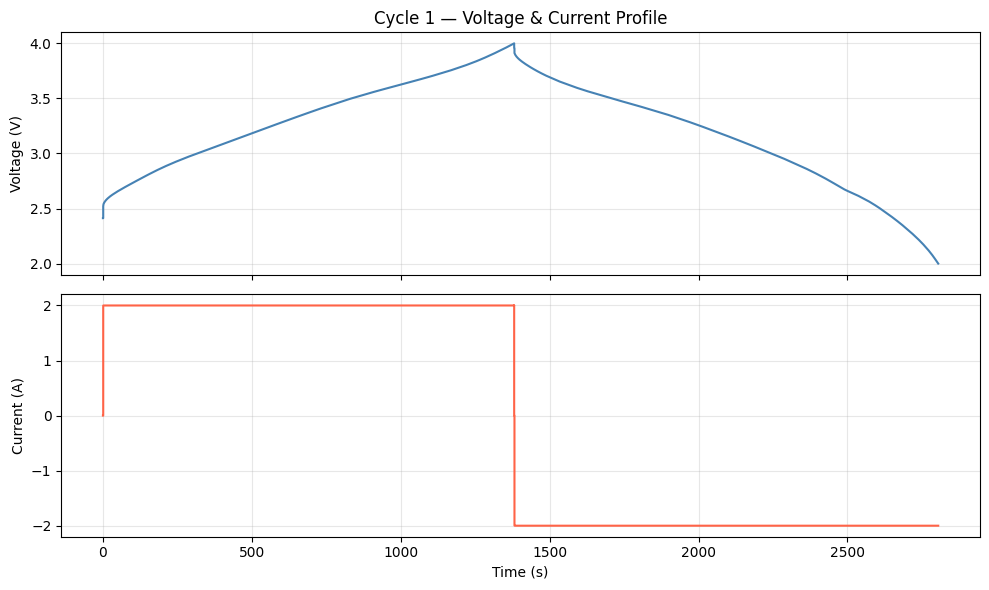

In [32]:
# Voltage and current profiles in single cycle
cycle_df = pd.DataFrame(sample['cycle_data'][0])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(cycle_df['time_in_s'], cycle_df['voltage_in_V'], color='steelblue')
ax1.set_ylabel('Voltage (V)')
ax1.set_title('Cycle 1 — Voltage & Current Profile')
ax1.grid(True, alpha=0.3)

ax2.plot(cycle_df['time_in_s'], cycle_df['current_in_A'], color='tomato')
ax2.set_ylabel('Current (A)')
ax2.set_xlabel('Time (s)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# find battery with most cycles
sample_file = max(all_files, key=lambda f: len(pd.read_pickle(os.path.join(data_dir, f))['cycle_data']))
sample = pd.read_pickle(os.path.join(data_dir, sample_file))
print(sample_file, "—", len(sample['cycle_data']), "cycles")

NA-ion_270040-3-5-52.pkl — 251 cycles


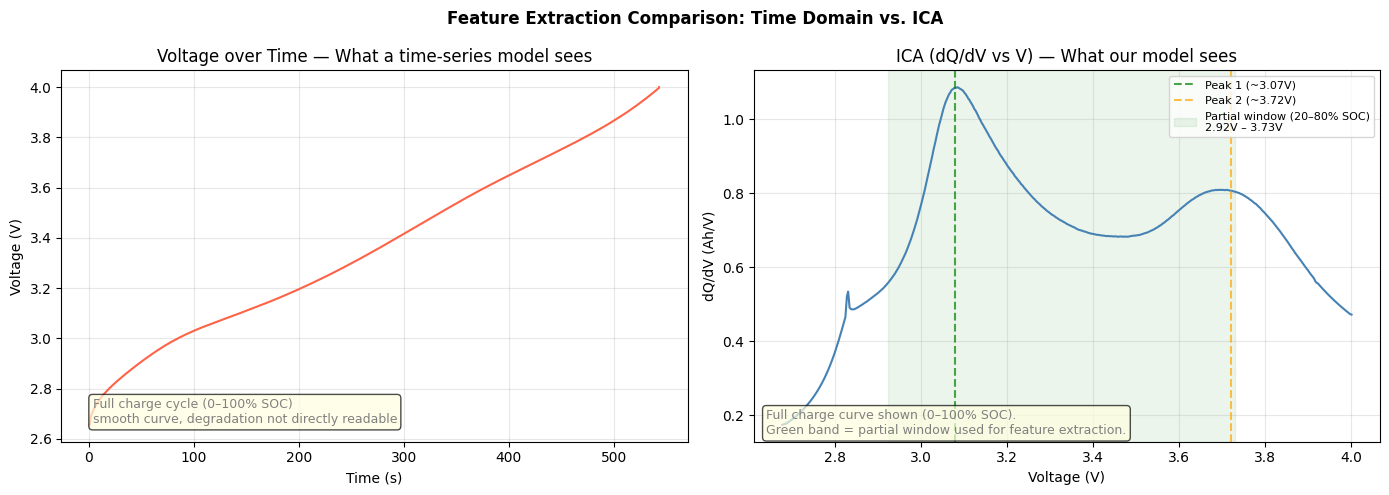

In [34]:
# Cell 3 — Why ICA? Time domain vs voltage domain

c_df = pd.DataFrame(sample['cycle_data'][0]).copy()
ch = c_df[c_df['current_in_A'] > 1.0].copy().reset_index(drop=True)

time_s = ch['time_in_s'].values
dt = np.diff(time_s, prepend=time_s[0])
dt[dt <= 0] = 1.0
ch['Cap'] = np.cumsum(ch['current_in_A'].values * dt / 3600)
ch['V_sg'] = savgol_filter(ch['voltage_in_V'], window_length=51, polyorder=3)
dQ = np.gradient(ch['Cap'])
dV = np.gradient(ch['V_sg'])
ch['dQdV'] = (dQ / (dV + 1e-6)).clip(-1, 3)

# partial window boundaries on ICA plot
v_min = ch['voltage_in_V'].min()
v_max = ch['voltage_in_V'].max()
v_20 = v_min + (v_max - v_min) * 0.20
v_80 = v_min + (v_max - v_min) * 0.80

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw voltage over time — full charge cycle (0-100%)
axes[0].plot(ch['time_in_s'], ch['voltage_in_V'], color='tomato', linewidth=1.5)
axes[0].set_title('Voltage over Time — What a time-series model sees')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Voltage (V)')
axes[0].grid(True, alpha=0.3)
axes[0].annotate('Full charge cycle (0–100% SOC)\nsmooth curve, degradation not directly readable',
                 xy=(0.05, 0.05), xycoords='axes fraction',
                 fontsize=9, color='gray',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Right: ICA — what our model sees
axes[1].plot(ch['V_sg'], ch['dQdV'], color='steelblue', linewidth=1.5)
axes[1].axvline(x=3.08, color='green', linestyle='--', alpha=0.7, label='Peak 1 (~3.07V)')
axes[1].axvline(x=3.72, color='orange', linestyle='--', alpha=0.7, label='Peak 2 (~3.72V)')
axes[1].axvspan(v_20, v_80, alpha=0.08, color='green', label=f'Partial window (20–80% SOC)\n{v_20:.2f}V – {v_80:.2f}V')
axes[1].set_title('ICA (dQ/dV vs V) — What our model sees')
axes[1].set_xlabel('Voltage (V)')
axes[1].set_ylabel('dQ/dV (Ah/V)')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].annotate('Full charge curve shown (0–100% SOC).\nGreen band = partial window used for feature extraction.',
                 xy=(0.02, 0.02), xycoords='axes fraction',
                 fontsize=9, color='gray',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.suptitle('Feature Extraction Comparison: Time Domain vs. ICA', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# two peaks correspond to electrochemical phase transitions in Na-ion cell
# peak height and position change with cycling and are strong predictors of capacity fade
# partial window focuses on mid-SOC region where degradation effects are more pronounced and less noisy than low/high SOC extremes

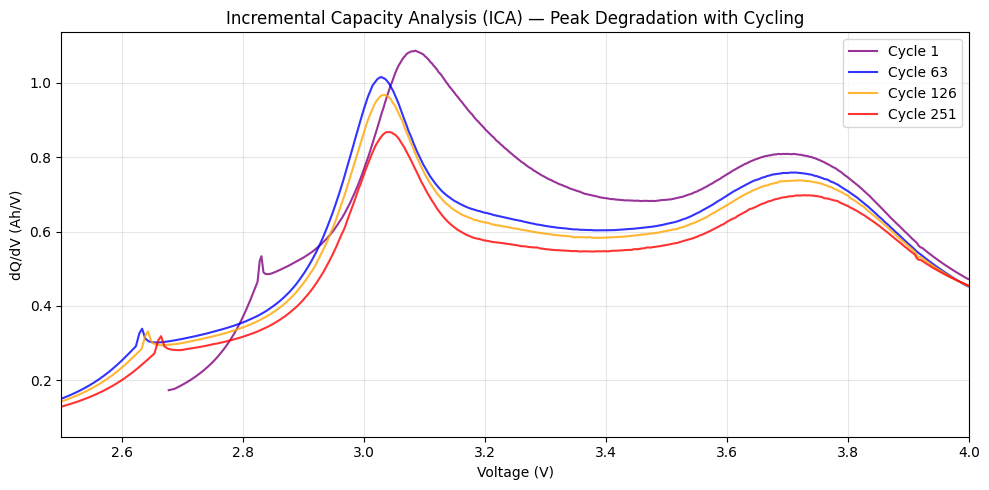

In [35]:
# Cell 3 — ICA on multiple cycles
n_cycles = len(sample['cycle_data'])
cycles_to_plot = [0, n_cycles//4, n_cycles//2, n_cycles-1]
colors = ['purple', 'blue', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 5))

for idx, c_idx in enumerate(cycles_to_plot):
    c_df = pd.DataFrame(sample['cycle_data'][c_idx]).copy()
    
    v_col = 'voltage_in_V'
    i_col = 'current_in_A'
    
    ch = c_df[c_df[i_col] > 1.0].copy().reset_index(drop=True)
    if len(ch) < 51:
        continue
    
    # Use actual time column instead of fixed timestep
    time_s = ch['time_in_s'].values
    dt = np.diff(time_s, prepend=time_s[0])
    dt[dt <= 0] = 1.0  # fix zero or negative intervals
    
    ch['Cap'] = np.cumsum(ch[i_col].values * dt / 3600)
    
    w = 51 if len(ch) > 51 else (len(ch)-1 if len(ch)%2==0 else len(ch))
    ch['V_s'] = savgol_filter(ch[v_col], window_length=w, polyorder=3)
    dQ = np.gradient(ch['Cap'])
    dV = np.gradient(ch['V_s'])
    ch['dQdV'] = dQ / (dV + 1e-6)
    ch['dQdV'] = ch['dQdV'].clip(-2, 10)
    
    ax.plot(ch['V_s'], ch['dQdV'],
            color=colors[idx],
            label=f'Cycle {c_idx+1}',
            alpha=0.8, linewidth=1.5)

ax.set_xlabel('Voltage (V)')
ax.set_ylabel('dQ/dV (Ah/V)')
ax.set_title('Incremental Capacity Analysis (ICA) — Peak Degradation with Cycling')
ax.legend()
ax.set_xlim(2.5, 4.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---Model Development----

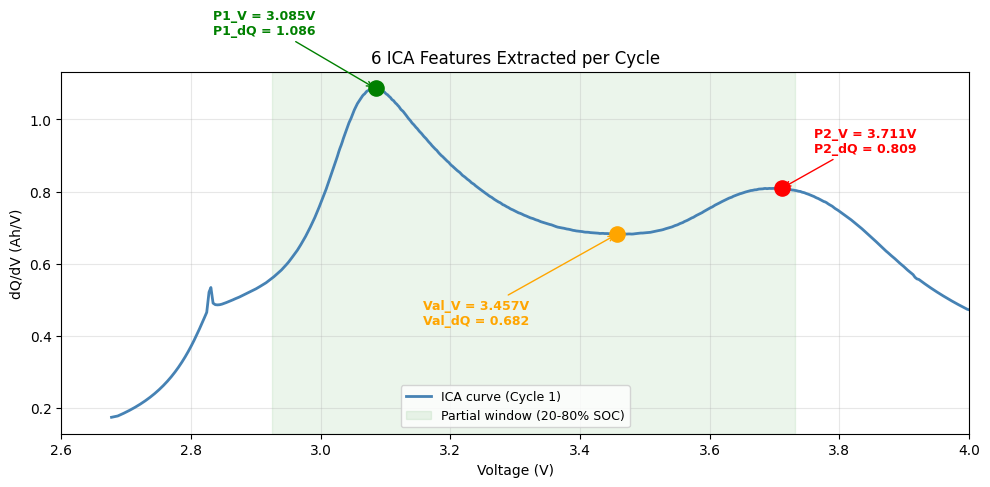

Extracted features from Cycle 1:
  P1_V   = 3.0847 V   (Peak 1 voltage)
  P1_dQ  = 1.0861    (Peak 1 height)
  Val_V  = 3.4573 V   (Valley voltage)
  Val_dQ = 0.6819    (Valley height)
  P2_V   = 3.7110 V   (Peak 2 voltage)
  P2_dQ  = 0.8088    (Peak 2 height)


In [36]:
# Cell 4 — Feature extraction visualization: what are the 6 features?
# Single cycle, show exactly what we extract

c_df = pd.DataFrame(sample['cycle_data'][0]).copy()
ch = c_df[c_df['current_in_A'] > 1.0].copy().reset_index(drop=True)

time_s = ch['time_in_s'].values
dt = np.diff(time_s, prepend=time_s[0])
dt[dt <= 0] = 1.0
ch['Cap'] = np.cumsum(ch['current_in_A'].values * dt / 3600)
ch['V_s'] = savgol_filter(ch['voltage_in_V'], window_length=51, polyorder=3)
dQ = np.gradient(ch['Cap'])
dV = np.gradient(ch['V_s'])
ch['dQdV'] = (dQ / (dV + 1e-6)).clip(-1, 3)

# find peaks and valley
m1 = (ch['V_s'] >= 2.7) & (ch['V_s'] <= 3.2)
m2 = (ch['V_s'] >= 3.4) & (ch['V_s'] <= 3.9)

idx1   = ch.loc[m1, 'dQdV'].idxmax()
idx2   = ch.loc[m2, 'dQdV'].idxmax()
v1, dq1 = ch.loc[idx1, ['V_s', 'dQdV']]
v2, dq2 = ch.loc[idx2, ['V_s', 'dQdV']]

m_val  = (ch['V_s'] > v1) & (ch['V_s'] < v2)
idx_v  = ch.loc[m_val, 'dQdV'].idxmin()
v_val, dq_val = ch.loc[idx_v, ['V_s', 'dQdV']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ch['V_s'], ch['dQdV'], color='steelblue', linewidth=2, label='ICA curve (Cycle 1)')

# Peak 1
ax.scatter(v1, dq1, color='green', s=120, zorder=5)
ax.annotate(f'P1_V = {v1:.3f}V\nP1_dQ = {dq1:.3f}',
            xy=(v1, dq1), xytext=(v1-0.25, dq1+0.15),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=9, color='green', fontweight='bold')

# Valley
ax.scatter(v_val, dq_val, color='orange', s=120, zorder=5)
ax.annotate(f'Val_V = {v_val:.3f}V\nVal_dQ = {dq_val:.3f}',
            xy=(v_val, dq_val), xytext=(v_val-0.3, dq_val-0.25),
            arrowprops=dict(arrowstyle='->', color='orange'),
            fontsize=9, color='orange', fontweight='bold')

# Peak 2
ax.scatter(v2, dq2, color='red', s=120, zorder=5)
ax.annotate(f'P2_V = {v2:.3f}V\nP2_dQ = {dq2:.3f}',
            xy=(v2, dq2), xytext=(v2+0.05, dq2+0.1),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red', fontweight='bold')

# partial window shading
v_min = ch['voltage_in_V'].min()
v_max = ch['voltage_in_V'].max()
ax.axvspan(v_min + (v_max-v_min)*0.20,
           v_min + (v_max-v_min)*0.80,
           alpha=0.08, color='green', label='Partial window (20-80% SOC)')

ax.set_xlabel('Voltage (V)')
ax.set_ylabel('dQ/dV (Ah/V)')
ax.set_title('6 ICA Features Extracted per Cycle')
ax.legend(fontsize=9)
ax.set_xlim(2.6, 4.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Extracted features from Cycle 1:")
print(f"  P1_V   = {v1:.4f} V   (Peak 1 voltage)")
print(f"  P1_dQ  = {dq1:.4f}    (Peak 1 height)")
print(f"  Val_V  = {v_val:.4f} V   (Valley voltage)")
print(f"  Val_dQ = {dq_val:.4f}    (Valley height)")
print(f"  P2_V   = {v2:.4f} V   (Peak 2 voltage)")
print(f"  P2_dQ  = {dq2:.4f}    (Peak 2 height)")

**Model Generation**

In [37]:
# Cell 4 — Feature extraction + XGBoost (full charge 0-100%)

def extract_features(file_path, partial_lower=None, partial_upper=None):
    try:
        data = pd.read_pickle(file_path)
        cycles = data['cycle_data']
        results = []
        for c_idx in range(len(cycles)):
            c_df = pd.DataFrame(cycles[c_idx])
            v_col = 'voltage_in_V'
            i_col = 'current_in_A'
            
            dis_mask = c_df[i_col] < -1.0
            df_dis = c_df[dis_mask]
            if df_dis.empty:
                continue

            if partial_lower is None:
                ch_mask = c_df[i_col] > 1.0
            else:
                full_ch = c_df[c_df[i_col] > 1.0]
                if full_ch.empty:
                    continue
                v_min = full_ch[v_col].min()
                v_max = full_ch[v_col].max()
                v_low  = v_min + (v_max - v_min) * partial_lower
                v_high = v_min + (v_max - v_min) * partial_upper
                ch_mask = (c_df[i_col] > 1.0) & (c_df[v_col] >= v_low) & (c_df[v_col] <= v_high)

            df_ch = c_df[ch_mask].copy().reset_index(drop=True)
            if df_ch.empty:
                continue

            time_s = df_ch['time_in_s'].values
            dt = np.diff(time_s, prepend=time_s[0])
            dt[dt <= 0] = 1.0
            df_ch['Cap'] = np.cumsum(df_ch[i_col].values * dt / 3600)

            w = 51 if len(df_ch) > 51 else (len(df_ch)-1 if len(df_ch)%2==0 else 3)
            if w <= 3:
                continue
            df_ch['V_s'] = savgol_filter(df_ch[v_col], window_length=w, polyorder=3)
            dQ = np.gradient(df_ch['Cap'])
            dV = np.gradient(df_ch['V_s'])
            df_ch['dQdV'] = dQ / (dV + 1e-6)

            m1 = (df_ch['V_s'] >= 2.7) & (df_ch['V_s'] <= 3.2)
            m2 = (df_ch['V_s'] >= 3.4) & (df_ch['V_s'] <= 3.9)
            if df_ch[m1].empty or df_ch[m2].empty:
                continue

            idx1 = df_ch.loc[m1, 'dQdV'].idxmax()
            idx2 = df_ch.loc[m2, 'dQdV'].idxmax()
            v1, dq1 = df_ch.loc[idx1, ['V_s', 'dQdV']]
            v2, dq2 = df_ch.loc[idx2, ['V_s', 'dQdV']]

            m_val = (df_ch['V_s'] > v1) & (df_ch['V_s'] < v2)
            if df_ch[m_val].empty:
                continue
            idx_v = df_ch.loc[m_val, 'dQdV'].idxmin()
            v_val, dq_val = df_ch.loc[idx_v, ['V_s', 'dQdV']]

            true_cap = (abs(df_dis[i_col]) * (df_dis['time_in_s'].diff().fillna(1).values) / 3600).sum()

            results.append({
                'P1_V': v1,    'P1_dQ':  dq1,
                'Val_V': v_val,'Val_dQ': dq_val,
                'P2_V': v2,    'P2_dQ':  dq2,
                'cap':  true_cap
            })
        return results
    except Exception as e:
        return []

# train/test split — last file as blind test
random.seed(42)
blind_5     = random.sample(all_files, 5)
train_files = [f for f in all_files if f not in blind_5]

feature_cols = ['P1_V','P1_dQ','Val_V','Val_dQ','P2_V','P2_dQ']

print("Extracting features — full charge (0-100%)...")
master = []
for f in train_files:
    master.extend(extract_features(os.path.join(data_dir, f)))

df_train = pd.DataFrame(master).dropna()
print(f"Training cycles: {len(df_train)}")

model_full = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.03,
    max_depth=7, subsample=0.8,
    random_state=42, verbosity=0)
model_full.fit(df_train[feature_cols], df_train['cap'])

# blind test — 5 unseen batteries
all_true, all_pred = [], []
for f in blind_5:
    rows = extract_features(os.path.join(data_dir, f))
    df_te = pd.DataFrame(rows).dropna(subset=feature_cols+['cap'])
    if df_te.empty:
        continue
    y_true = df_te['cap'].values
    y_pred = model_full.predict(df_te[feature_cols])
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    acc15 = np.mean(np.abs((y_true - y_pred) / y_true) <= 0.15) * 100
    all_true.extend(y_true)
    all_pred.extend(y_pred)
    print(f"  {f[-20:]:>22}  MAPE: {mape:.2f}%  15%-Acc: {acc15:.1f}%")

all_true = np.array(all_true)
all_pred = np.array(all_pred)
mape_full  = mean_absolute_percentage_error(all_true, all_pred) * 100
acc15_full = np.mean(np.abs((all_true - all_pred) / all_true) <= 0.15) * 100
print(f"\nFull charge — MAPE: {mape_full:.3f}%  |  15%-Accuracy: {acc15_full:.1f}%")

Extracting features — full charge (0-100%)...
Training cycles: 11776
    on_270040-2-7-12.pkl  MAPE: 0.71%  15%-Acc: 100.0%
    on_270040-1-4-61.pkl  MAPE: 0.22%  15%-Acc: 100.0%
    on_270040-5-4-36.pkl  MAPE: 1.77%  15%-Acc: 100.0%
    on_270040-4-8-41.pkl  MAPE: 0.66%  15%-Acc: 100.0%
    on_270040-4-5-44.pkl  MAPE: 0.93%  15%-Acc: 100.0%

Full charge — MAPE: 0.771%  |  15%-Accuracy: 100.0%


In [38]:
# Cell 5 — Same model, partial charge window (20-80% SOC)

print("Extracting features — partial charge (20-80%)...")
master_partial = []
for f in train_files:
    master_partial.extend(extract_features(os.path.join(data_dir, f), 
                                           partial_lower=0.20, partial_upper=0.80))

df_train_partial = pd.DataFrame(master_partial).dropna()
print(f"Training cycles: {len(df_train_partial)}")

model_partial = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.03,
    max_depth=7, subsample=0.8,
    random_state=42, verbosity=0)
model_partial.fit(df_train_partial[feature_cols], df_train_partial['cap'])

# blind test — same 5 batteries
all_true_p, all_pred_p = [], []
for f in blind_5:
    rows = extract_features(os.path.join(data_dir, f), 
                            partial_lower=0.20, partial_upper=0.80)
    df_te = pd.DataFrame(rows).dropna(subset=feature_cols+['cap'])
    if df_te.empty:
        continue
    y_true = df_te['cap'].values
    y_pred = model_partial.predict(df_te[feature_cols])
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    acc15 = np.mean(np.abs((y_true - y_pred) / y_true) <= 0.15) * 100
    all_true_p.extend(y_true)
    all_pred_p.extend(y_pred)
    print(f"  {f[-20:]:>22}  MAPE: {mape:.2f}%  15%-Acc: {acc15:.1f}%")

all_true_p = np.array(all_true_p)
all_pred_p = np.array(all_pred_p)
mape_partial  = mean_absolute_percentage_error(all_true_p, all_pred_p) * 100
acc15_partial = np.mean(np.abs((all_true_p - all_pred_p) / all_true_p) <= 0.15) * 100
print(f"\nPartial (20-80%) — MAPE: {mape_partial:.3f}%  |  15%-Accuracy: {acc15_partial:.1f}%")

# summary
print(f"\n{'='*45}")
print(f"{'':25} {'MAPE':>8} {'15%-Acc':>9}")
print(f"{'-'*45}")
print(f"{'Full charge (0-100%)':<25} {mape_full:>7.3f}% {acc15_full:>8.1f}%")
print(f"{'Partial (20-80%)':<25} {mape_partial:>7.3f}% {acc15_partial:>8.1f}%")
print(f"{'='*45}")

Extracting features — partial charge (20-80%)...
Training cycles: 11774
    on_270040-2-7-12.pkl  MAPE: 0.58%  15%-Acc: 100.0%
    on_270040-1-4-61.pkl  MAPE: 0.17%  15%-Acc: 100.0%
    on_270040-5-4-36.pkl  MAPE: 1.67%  15%-Acc: 100.0%
    on_270040-4-8-41.pkl  MAPE: 0.67%  15%-Acc: 100.0%
    on_270040-4-5-44.pkl  MAPE: 0.65%  15%-Acc: 100.0%

Partial (20-80%) — MAPE: 0.640%  |  15%-Accuracy: 100.0%

                              MAPE   15%-Acc
---------------------------------------------
Full charge (0-100%)        0.771%    100.0%
Partial (20-80%)            0.640%    100.0%


In [39]:
# find meaningful accuracy threshold
for threshold in [0.15, 0.10, 0.075, 0.05, 0.025, 0.01]:
    acc_full = np.mean(np.abs((all_true - all_pred) / all_true) <= threshold) * 100
    acc_part = np.mean(np.abs((all_true_p - all_pred_p) / all_true_p) <= threshold) * 100
    print(f"±{threshold*100:.1f}%  →  Full: {acc_full:.1f}%  |  Partial 20-80: {acc_part:.1f}%")

±15.0%  →  Full: 100.0%  |  Partial 20-80: 100.0%
±10.0%  →  Full: 100.0%  |  Partial 20-80: 100.0%
±7.5%  →  Full: 100.0%  |  Partial 20-80: 100.0%
±5.0%  →  Full: 100.0%  |  Partial 20-80: 100.0%
±2.5%  →  Full: 97.1%  |  Partial 20-80: 96.8%
±1.0%  →  Full: 69.6%  |  Partial 20-80: 82.2%


**Analysis and Visualization**

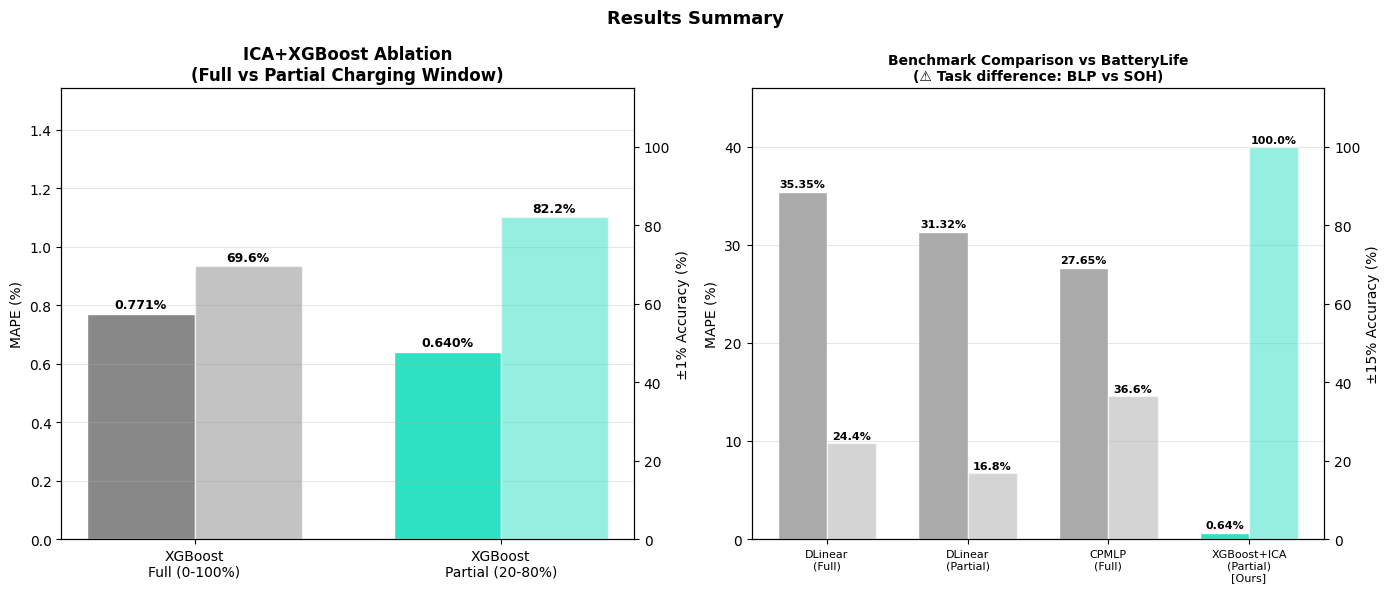

In [40]:
# Cell 7 — Comparison: ICA ablation + BatteryLife benchmark

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ============================================================
# Table 1: ICA Ablation — Full vs Partial (our models)
# ============================================================

ica_scenarios = ['XGBoost\nFull (0-100%)', 'XGBoost\nPartial (20-80%)']
ica_mapes     = [mape_full, mape_partial]
ica_acc1      = [
    np.mean(np.abs((all_true   - all_pred)   / all_true)   <= 0.01) * 100,
    np.mean(np.abs((all_true_p - all_pred_p) / all_true_p) <= 0.01) * 100,
]
ica_colors = ['#888888', '#2DE1C2']

ax = axes[0]
x = np.arange(len(ica_scenarios))
w = 0.35
b1 = ax.bar(x - w/2, ica_mapes, w, color=ica_colors, edgecolor='white', label='MAPE (%)')
ax2 = ax.twinx()
b2 = ax2.bar(x + w/2, ica_acc1, w, color=ica_colors, edgecolor='white', alpha=0.5, label='±1% Accuracy')

for bar, v in zip(b1, ica_mapes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{v:.3f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, v in zip(b2, ica_acc1):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('ICA+XGBoost Ablation\n(Full vs Partial Charging Window)', fontweight='bold')
ax.set_ylabel('MAPE (%)', color='black')
ax2.set_ylabel('±1% Accuracy (%)', color='black')
ax.set_xticks(x)
ax.set_xticklabels(ica_scenarios)
ax.set_ylim(0, max(ica_mapes) * 2)
ax2.set_ylim(0, 115)
ax.grid(True, alpha=0.3, axis='y')

# ============================================================
# Table 2: BatteryLife benchmark comparison
# ============================================================

bench_names  = ['DLinear\n(Full)', 'DLinear\n(Partial)', 'CPMLP\n(Full)', 
                 'XGBoost+ICA\n(Partial)\n[Ours]']
bench_mapes  = [35.35, 31.32, 27.65, mape_partial]
bench_acc15  = [24.40, 16.80, 36.60, 
                np.mean(np.abs((all_true_p - all_pred_p) / all_true_p) <= 0.15) * 100]
bench_colors = ['#aaaaaa', '#aaaaaa', '#aaaaaa', '#2DE1C2']

ax = axes[1]
x = np.arange(len(bench_names))
w = 0.35
b1 = ax.bar(x - w/2, bench_mapes, w, color=bench_colors, edgecolor='white')
ax2 = ax.twinx()
b2 = ax2.bar(x + w/2, bench_acc15, w, color=bench_colors, edgecolor='white', alpha=0.5)

for bar, v in zip(b1, bench_mapes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{v:.2f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar, v in zip(b2, bench_acc15):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Benchmark Comparison vs BatteryLife\n(⚠ Task difference: BLP vs SOH)', 
             fontweight='bold', fontsize=10)
ax.set_ylabel('MAPE (%)', color='black')
ax2.set_ylabel('±15% Accuracy (%)', color='black')
ax.set_xticks(x)
ax.set_xticklabels(bench_names, fontsize=8)
ax.set_ylim(0, max(bench_mapes) * 1.3)
ax2.set_ylim(0, 115)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Results Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Note: BatteryLife models perform Battery Life Prediction (BLP) — predicting total cycle life.
# Our model performs SOH estimation — predicting capacity at each cycle.
# Direct metric comparison is indicative only. Partial charging window (20-80% SOC)
# applied to both DLinear and our model for fair input-side comparison.
# DLinear partial result from our fork experiment (myz_model_setup_naion.ipynb).

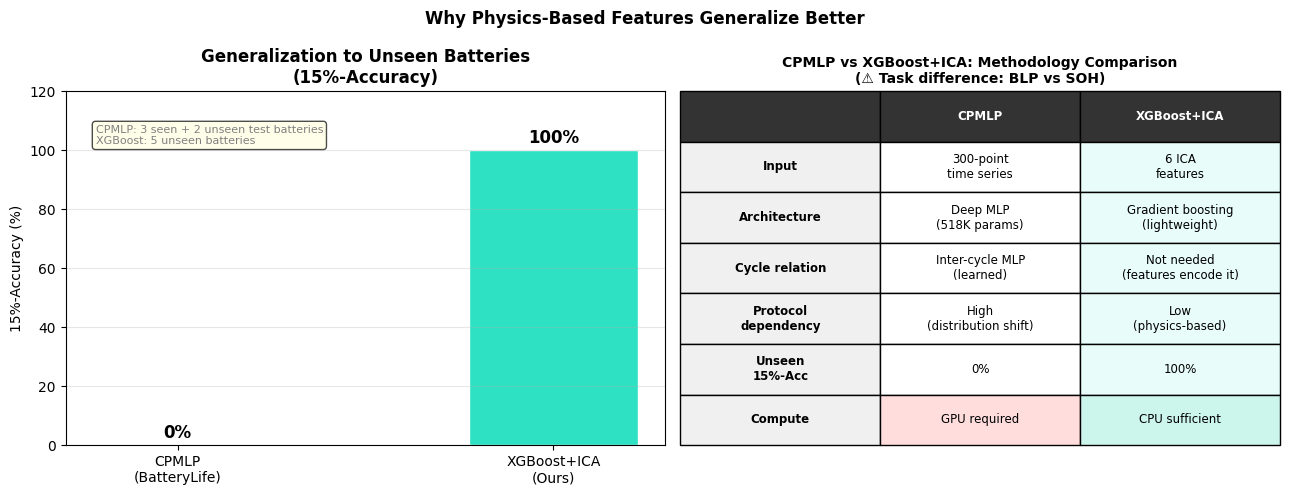

In [41]:
# Cell 8 — CPMLP vs XGBoost+ICA: methodology comparison

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: unseen generalization — the key difference
models     = ['CPMLP\n(BatteryLife)', 'XGBoost+ICA\n(Ours)']
unseen_acc = [0.0, 100.0]
colors     = ['#aaaaaa', '#2DE1C2']

ax = axes[0]
bars = ax.bar(models, unseen_acc, color=colors, edgecolor='white', width=0.45)
for bar, v in zip(bars, unseen_acc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{v:.0f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Generalization to Unseen Batteries\n(15%-Accuracy)', fontweight='bold')
ax.set_ylabel('15%-Accuracy (%)')
ax.set_ylim(0, 120)
ax.grid(True, alpha=0.3, axis='y')
ax.annotate('CPMLP: 3 seen + 2 unseen test batteries\nXGBoost: 5 unseen batteries',
            xy=(0.05, 0.85), xycoords='axes fraction',
            fontsize=8, color='gray',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Right: methodology diagram
ax = axes[1]
ax.axis('off')

data = [
    ['', 'CPMLP', 'XGBoost+ICA'],
    ['Input', '300-point\ntime series', '6 ICA\nfeatures'],
    ['Architecture', 'Deep MLP\n(518K params)', 'Gradient boosting\n(lightweight)'],
    ['Cycle relation', 'Inter-cycle MLP\n(learned)', 'Not needed\n(features encode it)'],
    ['Protocol\ndependency', 'High\n(distribution shift)', 'Low\n(physics-based)'],
    ['Unseen\n15%-Acc', '0%', '100%'],
    ['Compute', 'GPU required', 'CPU sufficient'],
]

table = ax.table(cellText=data[1:],
                 colLabels=data[0],
                 cellLoc='center', loc='center',
                 bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(8.5)

for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#333333')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 0:
        cell.set_facecolor('#f0f0f0')
        cell.set_text_props(fontweight='bold')
    elif c == 2:
        cell.set_facecolor('#e8fdf9')
    if r == 6:  # unseen row
        if c == 1:
            cell.set_facecolor('#ffdddd')
        elif c == 2:
            cell.set_facecolor('#ccf5ec')

ax.set_title('CPMLP vs XGBoost+ICA: Methodology Comparison\n'
             '(⚠ Task difference: BLP vs SOH)',
             fontweight='bold', fontsize=10)

plt.suptitle('Why Physics-Based Features Generalize Better', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cpmlp_vs_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insight: CPMLP learns from raw signal distribution — 
# when protocol changes, distribution shifts and model fails.
# XGBoost learns from electrochemical phase transition signatures —
# these are protocol-independent, model generalizes.

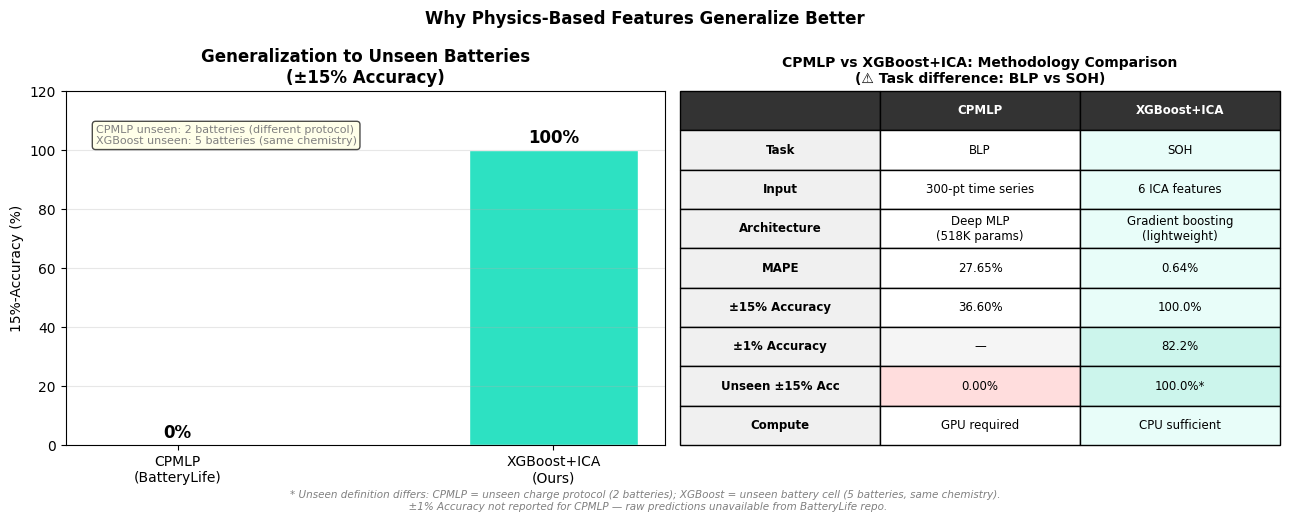

In [42]:
# Cell 8 — CPMLP vs XGBoost+ICA: methodology comparison

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: unseen generalization
models     = ['CPMLP\n(BatteryLife)', 'XGBoost+ICA\n(Ours)']
unseen_acc = [0.0, 100.0]
colors     = ['#aaaaaa', '#2DE1C2']

ax = axes[0]
bars = ax.bar(models, unseen_acc, color=colors, edgecolor='white', width=0.45)
for bar, v in zip(bars, unseen_acc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{v:.0f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Generalization to Unseen Batteries\n(±15% Accuracy)', fontweight='bold')
ax.set_ylabel('15%-Accuracy (%)')
ax.set_ylim(0, 120)
ax.grid(True, alpha=0.3, axis='y')
ax.annotate('CPMLP unseen: 2 batteries (different protocol)\n'
            'XGBoost unseen: 5 batteries (same chemistry)',
            xy=(0.05, 0.85), xycoords='axes fraction',
            fontsize=8, color='gray',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Right: comparison table
ax = axes[1]
ax.axis('off')

data = [
    ['',                  'CPMLP',              'XGBoost+ICA'],
    ['Task',              'BLP',                'SOH'],
    ['Input',             '300-pt time series', '6 ICA features'],
    ['Architecture',      'Deep MLP\n(518K params)', 'Gradient boosting\n(lightweight)'],
    ['MAPE',              '27.65%',             f'{mape_partial:.2f}%'],
    ['±15% Accuracy',     '36.60%',             '100.0%'],
    ['±1% Accuracy',      '—',                  f'{np.mean(np.abs((all_true_p - all_pred_p) / all_true_p) <= 0.01)*100:.1f}%'],
    ['Unseen ±15% Acc',   '0.00%',              '100.0%*'],
    ['Compute',           'GPU required',       'CPU sufficient'],
]

table = ax.table(cellText=data[1:],
                 colLabels=data[0],
                 cellLoc='center', loc='center',
                 bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(8.5)

for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#333333')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 0:
        cell.set_facecolor('#f0f0f0')
        cell.set_text_props(fontweight='bold')
    elif c == 2:
        cell.set_facecolor('#e8fdf9')
    # highlight unseen and accuracy rows
    if r == 7:  # unseen row
        if c == 1:
            cell.set_facecolor('#ffdddd')
        elif c == 2:
            cell.set_facecolor('#ccf5ec')
    if r == 6:  # ±1% row — only ours has it
        if c == 1:
            cell.set_facecolor('#f5f5f5')
        elif c == 2:
            cell.set_facecolor('#ccf5ec')

ax.set_title('CPMLP vs XGBoost+ICA: Methodology Comparison\n'
             '(⚠ Task difference: BLP vs SOH)',
             fontweight='bold', fontsize=10)

plt.suptitle('Why Physics-Based Features Generalize Better', fontsize=12, fontweight='bold')

# footnote
fig.text(0.5, -0.02,
         '* Unseen definition differs: CPMLP = unseen charge protocol (2 batteries); '
         'XGBoost = unseen battery cell (5 batteries, same chemistry).\n'
         '  ±1% Accuracy not reported for CPMLP — raw predictions unavailable from BatteryLife repo.',
         ha='center', fontsize=7.5, color='gray', style='italic')

plt.tight_layout()
plt.savefig('cpmlp_vs_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()